In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
urban = pd.read_csv('urbandata.csv')
urban.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [ ]:
len(urban)

456

In [ ]:
urban.isna().sum()

,0
inspector_id,0
material_flexibility,0
structural_mass_ratio,1
recent_precipitation,2
infrastructure_age,4
surface_debris,0
vibration_exposure,1
asset_density,0
inspection_season,0
inspection_window,0


In [ ]:
urban

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.99440,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.68080,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.52940,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.48100,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.04600,summer,morning,0.07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
451,5,30.154152,11.816298,2.120903,57.140895,8.778138,5.030630,2.53112,spring,afternoon,0.00,0
452,10,32.254170,11.779914,2.841949,61.490869,9.300330,4.930623,2.56308,autumn,night,0.02,0
453,6,28.465334,11.506094,0.000000,62.438486,8.169076,4.743956,2.20000,winter,afternoon,0.04,0
454,9,31.813525,12.015377,3.655757,54.803893,9.256184,4.990145,2.84280,summer,night,0.06,1


In [ ]:
urban[urban.isnull().any(axis=1)]

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
30,1,31.906319,11.812803,2.694545,55.774162,9.181269,4.886832,2.56692,autumn,morning,NaN,0
31,4,28.405858,11.681774,1.836554,63.334801,8.302755,4.955494,2.46240,autumn,night,NaN,0
32,9,32.064930,11.857232,3.660226,52.551259,9.048581,4.952309,2.73400,winter,afternoon,NaN,0
131,2,30.733149,11.575091,2.042268,66.392515,8.579636,NaN,2.39064,winter,night,0.01,0
188,2,36.636688,12.939398,5.207587,NaN,10.109317,5.057439,3.06920,summer,afternoon,0.02,1
212,10,29.858813,11.718220,NaN,50.800519,8.546346,4.876125,2.47016,winter,afternoon,0.01,0
376,2,34.777433,13.013540,5.406268,NaN,10.185214,4.988152,3.22000,summer,morning,0.06,1
380,3,36.419436,12.313568,4.531669,NaN,10.656180,4.961130,2.92800,autumn,night,0.03,1
413,3,30.036887,11.535464,1.123544,NaN,8.568975,4.993997,2.28088,summer,night,0.03,0
427,7,36.262647,12.226942,NaN,94.172578,11.078386,4.944079,2.85000,summer,afternoon,0.06,1


In [ ]:
len(urban[urban.isnull().any(axis=1)])

11

With 456 rows, removing 11 rows would not cause any issues and I cannot estimate values over there



In [ ]:
urban = urban.dropna()

In [ ]:
len(urban)

445

In [ ]:
urban.inspector_id.unique()

array([ 5,  7,  6,  2,  8,  9, 10,  1,  4,  3, 11])

So far there are 11 inspector id's

(array([191., 240.,  12.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([24.9247646 , 31.54807944, 38.17139428, 44.79470913, 51.41802397,
        58.04133881, 64.66465365, 71.28796849, 77.91128333, 84.53459817,
        91.15791301]),
 <BarContainer object of 10 artists>)

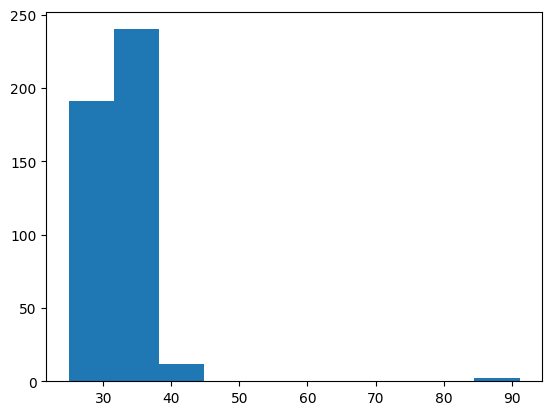

In [ ]:
plt.hist(urban.material_flexibility)

In [ ]:
min(urban.material_flexibility[urban.material_flexibility<50])

24.9247646027265

In [ ]:
max(urban.material_flexibility[urban.material_flexibility<50])

40.4529810930904

(array([  3.,  13.,  41., 103., 109.,  76.,  38.,  42.,  12.,   6.]),
 array([24.9247646 , 26.47758625, 28.0304079 , 29.58322955, 31.1360512 ,
        32.68887285, 34.2416945 , 35.79451615, 37.3473378 , 38.90015944,
        40.45298109]),
 <BarContainer object of 10 artists>)

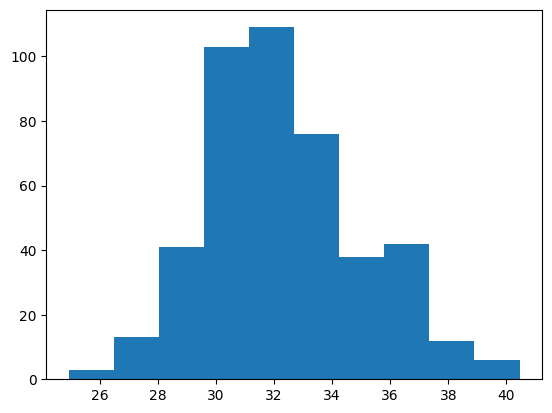

In [ ]:
plt.hist(urban.material_flexibility[urban.material_flexibility<50])

In [ ]:
import seaborn as sns

def plot_line(col):
  plt.figure(figsize=(10, 6))
  sns.kdeplot(urban[urban['failure'] == 0][col], color='blue', label='Failure = 0', fill=True)
  sns.kdeplot(urban[urban['failure'] == 1][col], color='red', label='Failure = 1', fill=True)
  plt.xlabel(col)
  plt.ylabel('Density')
  plt.title(f'Distribution of {col} by Failure Status')
  plt.legend();

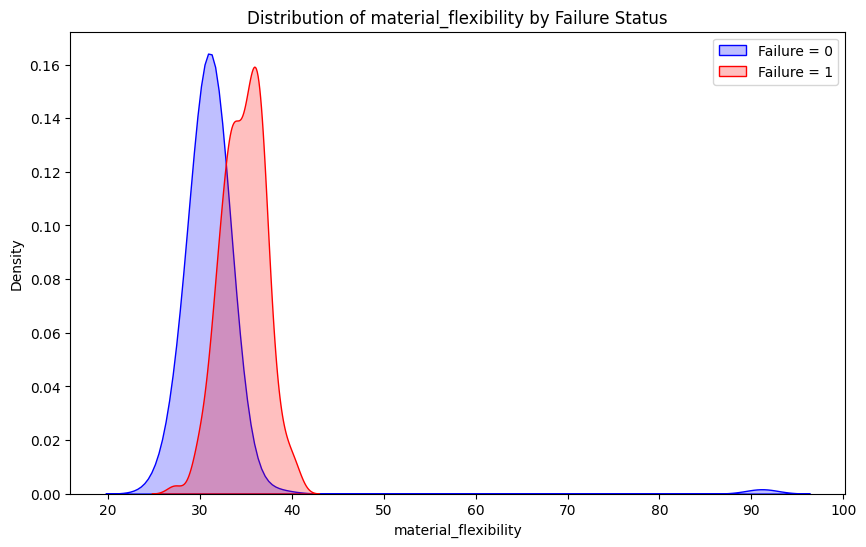

In [ ]:
plot_line('material_flexibility')

In [ ]:
urban.material_flexibility[urban.material_flexibility>50]

,material_flexibility
9,91.157913
421,91.157913


Would have used MinMaxScaler later but due to the nature of these outliers, I would be using the RobustScaler


(array([210.,  90.,  58.,  38.,  23.,   9.,   8.,   4.,   2.,   3.]),
 array([11.5060935 , 11.83783308, 12.16957266, 12.50131225, 12.83305183,
        13.16479141, 13.49653099, 13.82827057, 14.16001015, 14.49174974,
        14.82348932]),
 <BarContainer object of 10 artists>)

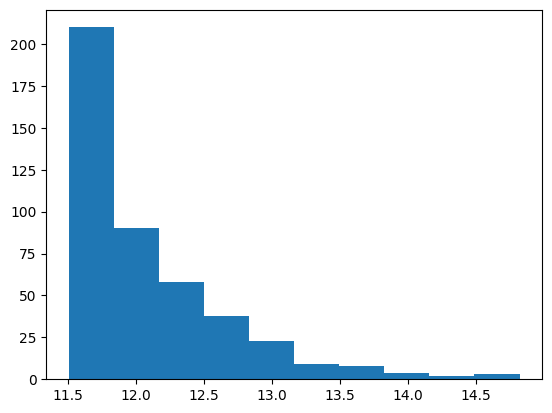

In [ ]:
plt.hist(urban.structural_mass_ratio)

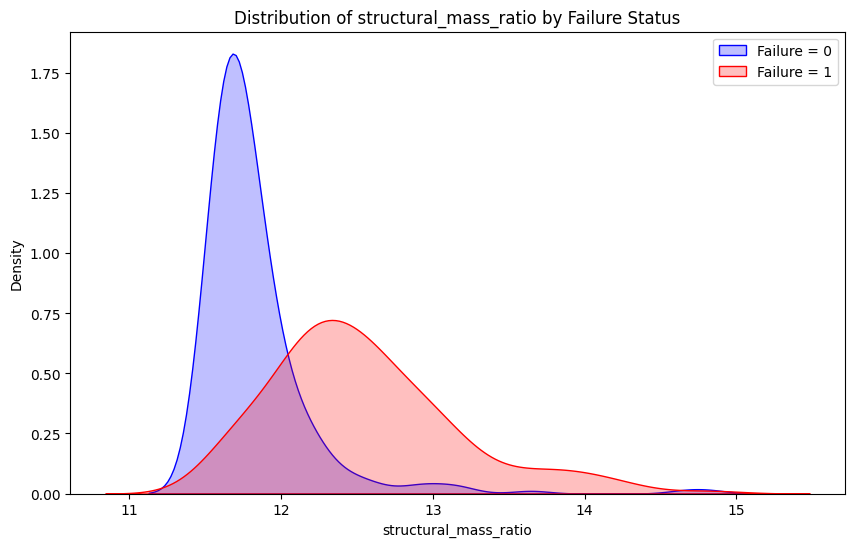

In [ ]:
plot_line('structural_mass_ratio')

(array([16., 19., 41., 76., 80., 42., 57., 71., 26., 17.]),
 array([0.        , 0.60890449, 1.21780898, 1.82671346, 2.43561795,
        3.04452244, 3.65342693, 4.26233141, 4.8712359 , 5.48014039,
        6.08904488]),
 <BarContainer object of 10 artists>)

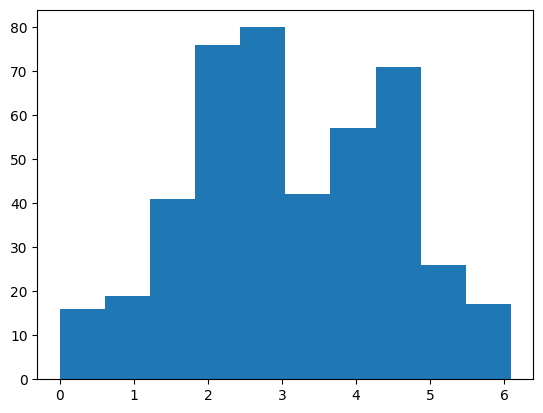

In [ ]:
plt.hist(urban.recent_precipitation)

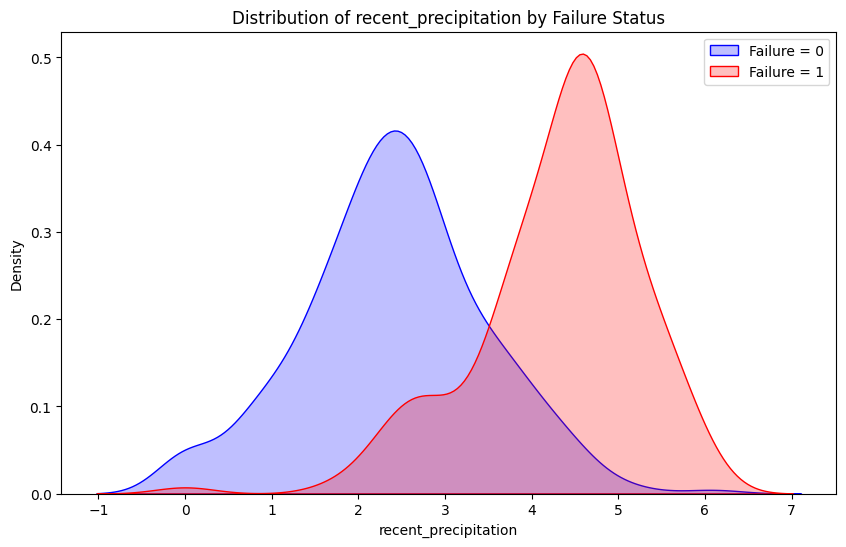

In [ ]:
plot_line('recent_precipitation')

(array([ 19.,  82., 144.,  75.,  46.,  40.,  25.,  11.,   1.,   2.]),
 array([ 41.08760222,  49.57379715,  58.05999208,  66.54618701,
         75.03238194,  83.51857687,  92.0047718 , 100.49096673,
        108.97716166, 117.46335659, 125.94955152]),
 <BarContainer object of 10 artists>)

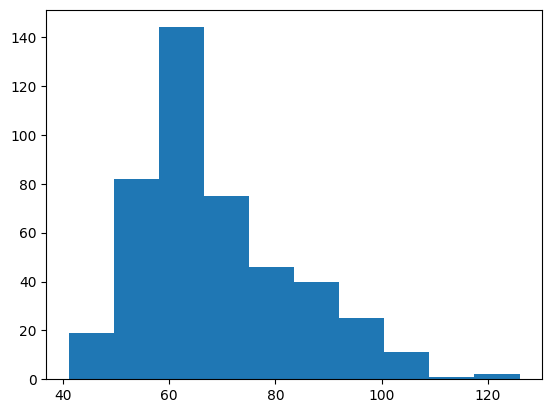

In [ ]:
plt.hist(urban.infrastructure_age)

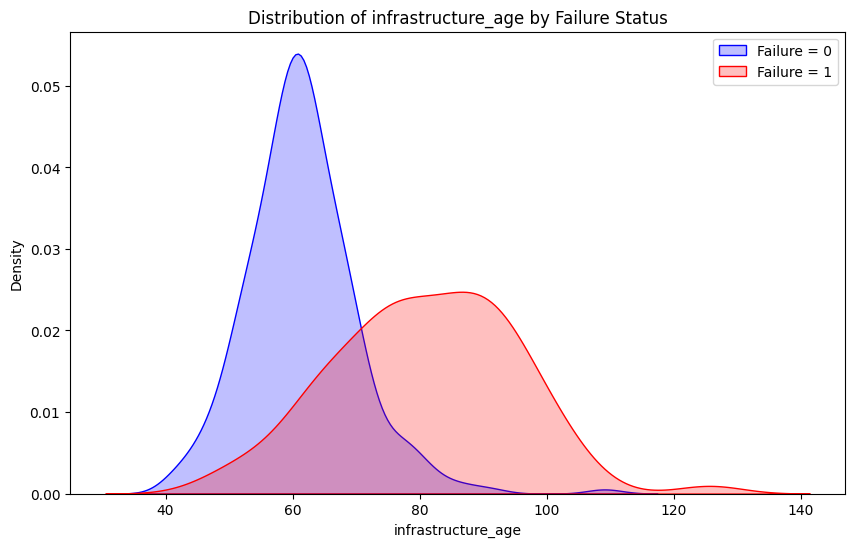

In [ ]:
plot_line('infrastructure_age')

(array([  8.,  30.,  62., 126.,  90.,  39.,  51.,  24.,  11.,   4.]),
 array([ 7.42692639,  7.85616155,  8.2853967 ,  8.71463185,  9.143867  ,
         9.57310215, 10.0023373 , 10.43157246, 10.86080761, 11.29004276,
        11.71927791]),
 <BarContainer object of 10 artists>)

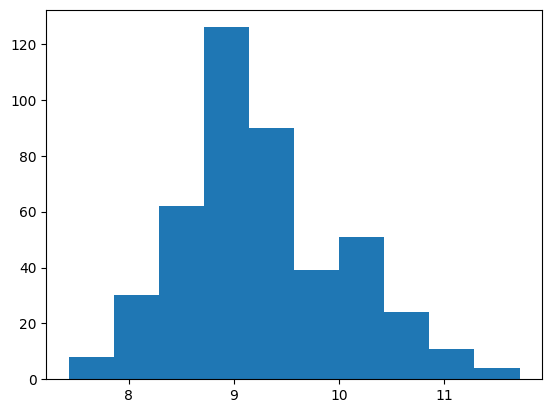

In [ ]:
plt.hist(urban.surface_debris)

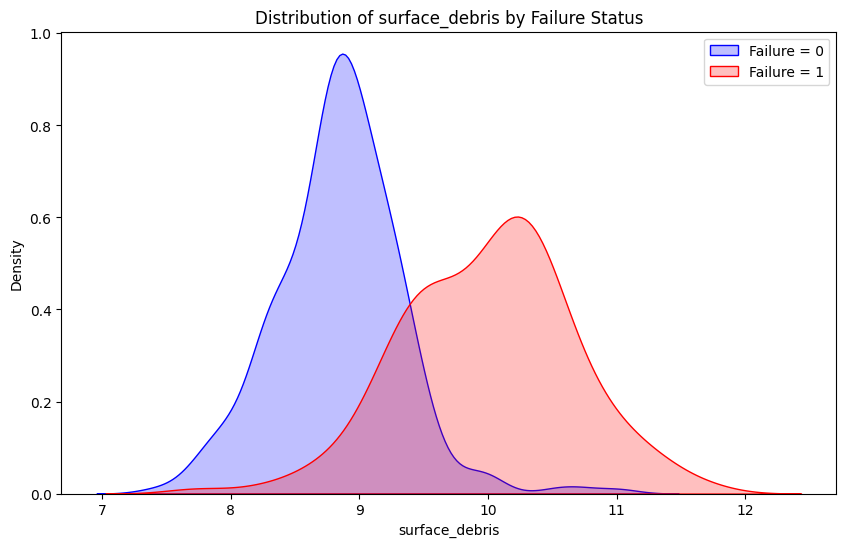

In [ ]:
plot_line('surface_debris')

(array([  6.,  20.,  59., 103., 120.,  75.,  34.,  19.,   7.,   2.]),
 array([4.74395648, 4.79446146, 4.84496644, 4.89547142, 4.9459764 ,
        4.99648138, 5.04698636, 5.09749134, 5.14799632, 5.1985013 ,
        5.24900628]),
 <BarContainer object of 10 artists>)

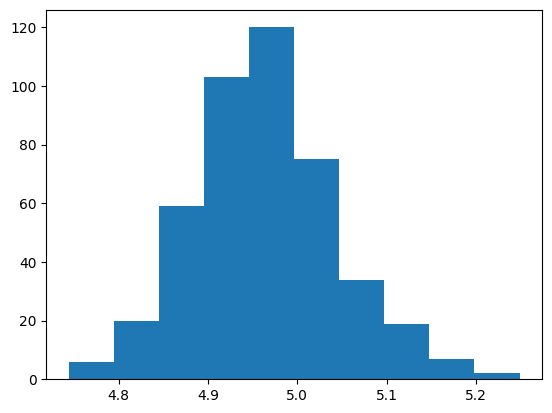

In [ ]:
plt.hist(urban.vibration_exposure)

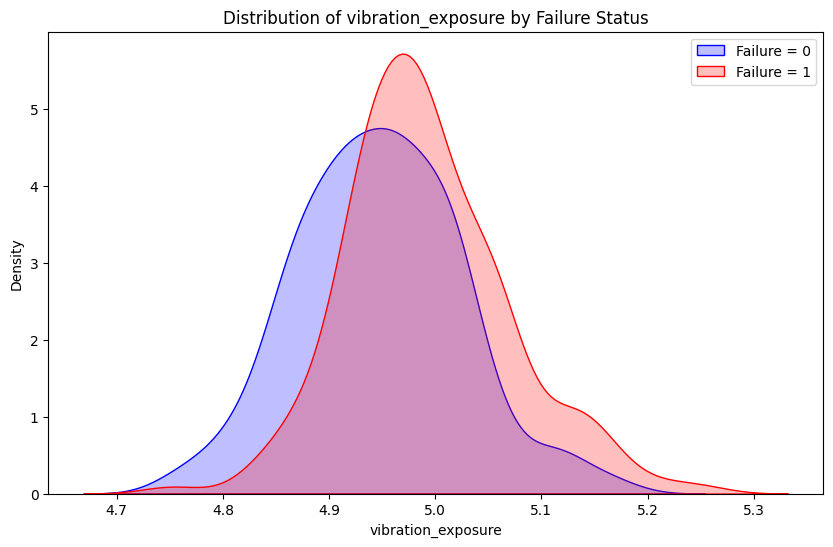

In [ ]:
plot_line('vibration_exposure')

(array([37., 58., 99., 73., 39., 47., 40., 25., 17., 10.]),
 array([2.2   , 2.3164, 2.4328, 2.5492, 2.6656, 2.782 , 2.8984, 3.0148,
        3.1312, 3.2476, 3.364 ]),
 <BarContainer object of 10 artists>)

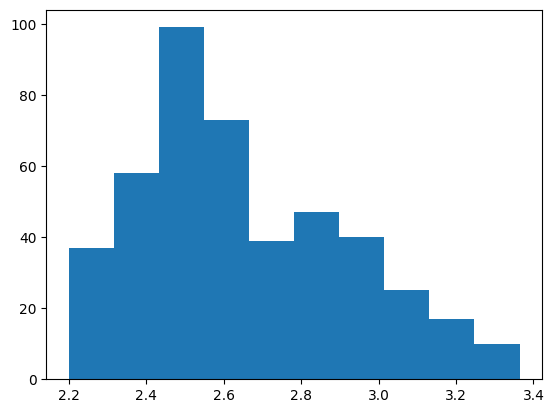

In [ ]:
plt.hist(urban.asset_density)

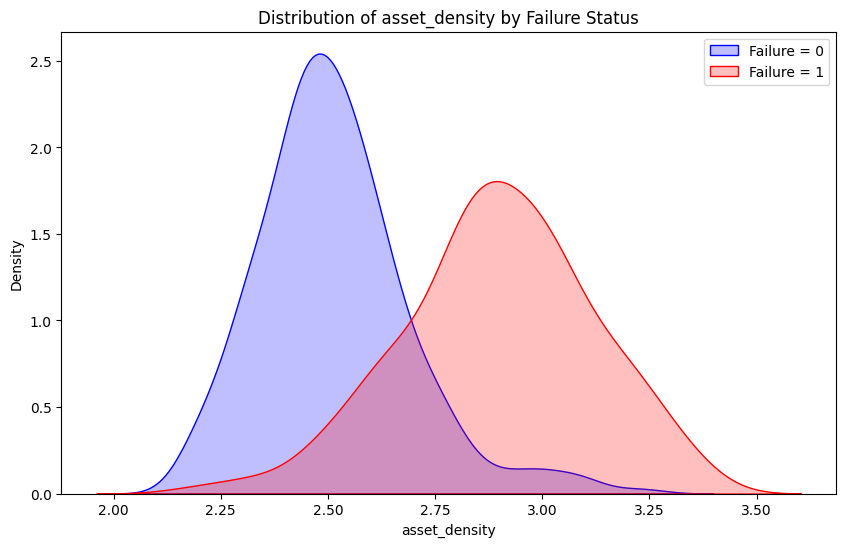

In [ ]:
plot_line('asset_density')

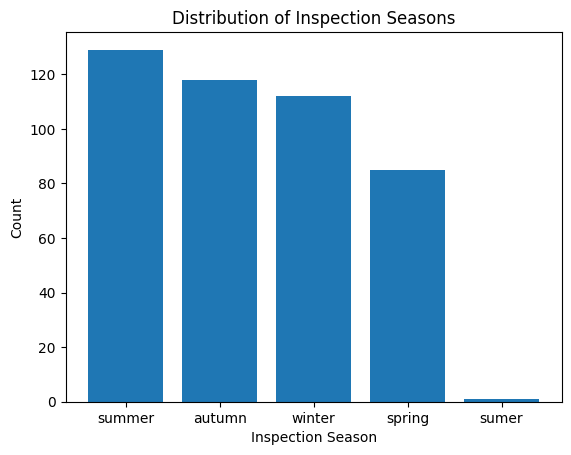

In [ ]:
season_counts = urban.inspection_season.value_counts()
plt.bar(season_counts.index, season_counts.values)
plt.xlabel('Inspection Season')
plt.ylabel('Count')
plt.title('Distribution of Inspection Seasons');

Summer was misspelled to sumer. Let me make that correction

In [ ]:
urban.inspection_season = urban.inspection_season.replace('sumer', 'summer')

/tmp/ipykernel_3066/3969128311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urban.inspection_season = urban.inspection_season.replace('sumer', 'summer')


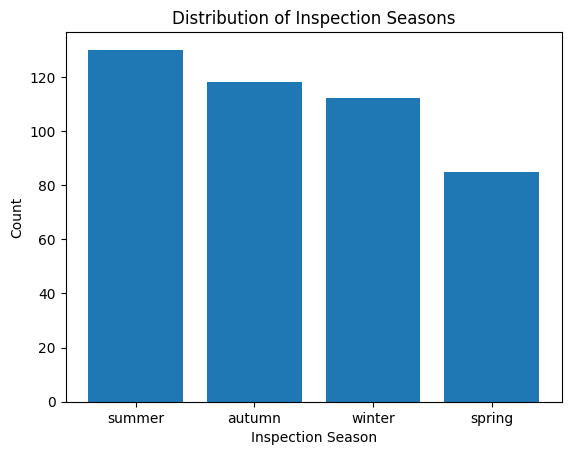

In [ ]:
season_counts = urban.inspection_season.value_counts()
plt.bar(season_counts.index, season_counts.values)
plt.xlabel('Inspection Season')
plt.ylabel('Count')
plt.title('Distribution of Inspection Seasons');

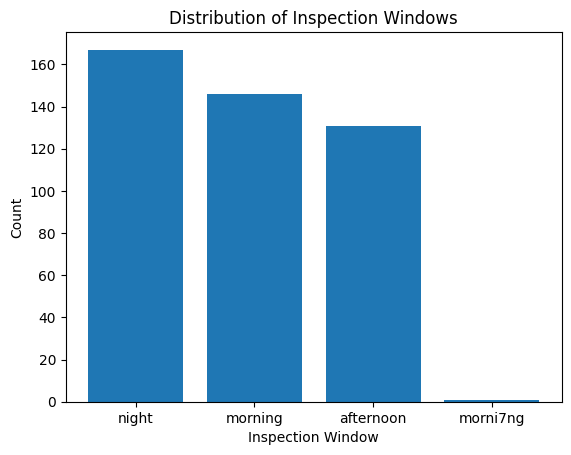

In [ ]:
window_counts = urban.inspection_window.value_counts()
plt.bar(window_counts.index, window_counts.values)
plt.xlabel('Inspection Window')
plt.ylabel('Count')
plt.title('Distribution of Inspection Windows');

This is the same thing that has happened. "Morning" has not been spelt well so I would have to make the necessary changes so that it falls under the right category.

In [ ]:
urban.inspection_window = urban.inspection_window.replace('morni7ng', 'morning')

/tmp/ipykernel_3066/1010450299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urban.inspection_window = urban.inspection_window.replace('morni7ng', 'morning')


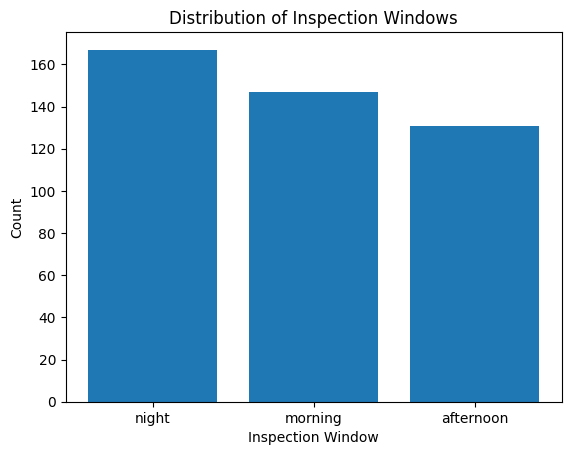

In [ ]:
window_counts = urban.inspection_window.value_counts()
plt.bar(window_counts.index, window_counts.values)
plt.xlabel('Inspection Window')
plt.ylabel('Count')
plt.title('Distribution of Inspection Windows');

(array([354.,  56.,  15.,   9.,   4.,   3.,   2.,   1.,   0.,   1.]),
 array([0.   , 0.048, 0.096, 0.144, 0.192, 0.24 , 0.288, 0.336, 0.384,
        0.432, 0.48 ]),
 <BarContainer object of 10 artists>)

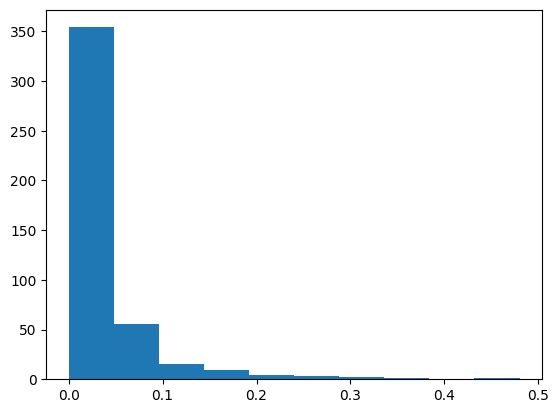

In [ ]:
plt.hist(urban.moisture_stress)

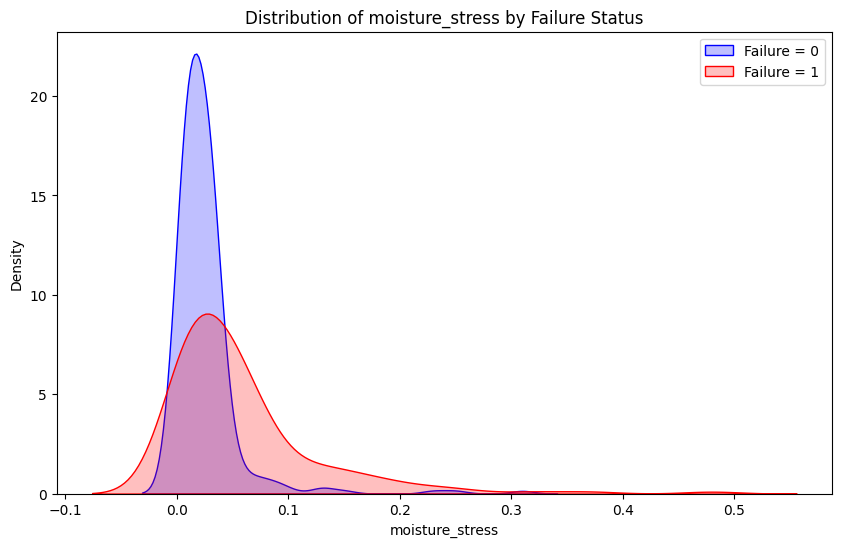

In [ ]:
plot_line('moisture_stress')

Text(0, 0.5, 'Count')

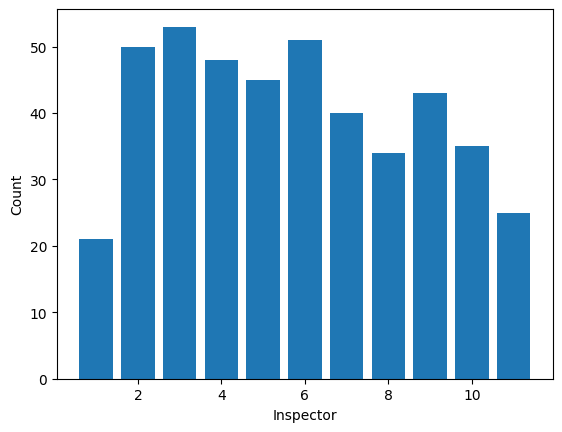

In [ ]:
inspector_counts = urban.inspector_id.value_counts()
plt.bar(inspector_counts.index, inspector_counts.values)
plt.xlabel('Inspector')
plt.ylabel('Count')

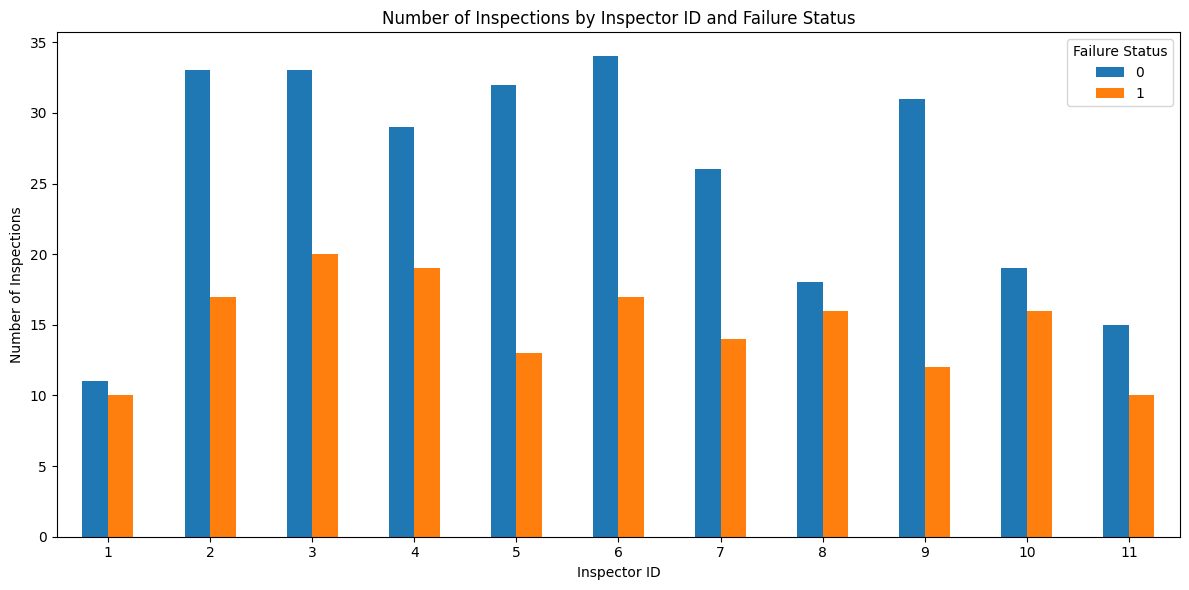

In [ ]:
failure_by_inspector = urban.groupby(['inspector_id', 'failure']).size().unstack(fill_value=0)
failure_by_inspector.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Inspections by Inspector ID and Failure Status')
plt.xlabel('Inspector ID')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=0)
plt.legend(title='Failure Status')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

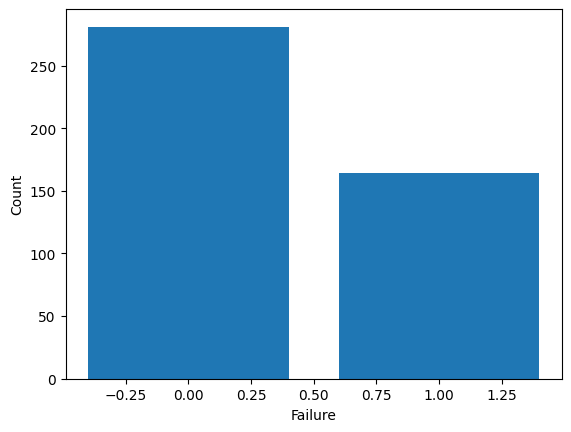

In [ ]:
failure_counts = urban.failure.value_counts()
plt.bar(failure_counts.index, failure_counts.values)
plt.xlabel('Failure')
plt.ylabel('Count')

In [ ]:
failure_counts.values

array([281, 164])

In [ ]:
urban.dtypes

,0
inspector_id,int64
material_flexibility,float64
structural_mass_ratio,float64
recent_precipitation,float64
infrastructure_age,float64
surface_debris,float64
vibration_exposure,float64
asset_density,float64
inspection_season,object
inspection_window,object


In [ ]:
urban_copy = urban.copy()
urban_copy = urban_copy[urban_copy.material_flexibility<50]

In [ ]:
y = urban_copy.failure
x = urban_copy.drop(columns=['failure'])

In [ ]:
x.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07


In [ ]:
y.head()

,failure
0,1
1,0
2,0
3,1
4,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train_transform = x_train.copy()
x_test_transform = x_test.copy()
x_train_transform2 = x_train.copy()
x_test_transform2 = x_test.copy()
x_train_transform3 = x_train.copy()
x_test_transform3 = x_test.copy()

In [ ]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
# import joblib

# ct = ColumnTransformer(
#     transformers = [
#         ("mm",MinMaxScaler(),numeric_features),
#         ("ohe",OneHotEncoder(sparse_output = False, handle_unknown="ignore", drop = "first"),columns_for_ohe),
#     ],
#     remainder = "passthrough",
#     verbose_feature_names_out = False
# )

# knn_pipeline = Pipeline(steps=[
#     ('preprocessor', ct),
#     ('model', KNeighborsClassifier())
# ])

In [ ]:
# models={ "Logistic Regression": Pipeline([
#         ('preprocessor', ct),
#         ('model', LogisticRegression(max_iter=1000))
#     ]),
#     "KNN": knn_pipeline,
#     "Random Forest": Pipeline([
#         ('preprocessor', ct),
#         ('model', RandomForestClassifier())
#     ])}
# def fit_and_score(models,X_train,X_test,y_train,y_test):
#     """
#     Fits and scores given Machine Learning Models.
#     models : A dict of different Sckit-Learn Machine Learning Models
#     X_train : Training Data (No labels)
#     X_test : Testing Data (No labels)
#     y_train : Training Labels
#     y_test : Test Labels
#     """
#     np.random.seed(42)
#     model_scores={}
#     #Loop through models
#     for name, model in models.items():
#         model.fit(X_train,y_train)
#         #Evaluate the model and append its score to model_scores
#         model_scores[name]=model.score(X_test,y_test)
#     return model_scores

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits models using 5-fold stratified cross-validation on training data,
    prints each fold score, then evaluates once on test set.
    """
    np.random.seed(42)
    model_scores = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f"\n===== {name} =====")

        # 1️⃣ Cross-validation on training set
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="recall"
        )

        # Print each fold score
        for i, score in enumerate(cv_scores, 1):
            print(f"Fold {i} Recall: {score:.4f}")

        print(f"Mean CV Recall: {cv_scores.mean():.4f}")

        # 2️⃣ Fit on full training data
        model.fit(X_train, y_train)

        # 3️⃣ Evaluate on test set
        y_pred = model.predict(X_test)
        test_score = recall_score(y_test, y_pred)

        print(f"Test Recall: {test_score:.4f}")

        model_scores[name] = {
            "CV Scores": cv_scores,
            "Mean CV Recall": cv_scores.mean(),
            "Test Recall": test_score
        }

    return model_scores

# def fit_and_score(models, X, y):
#     np.random.seed(42)
#     model_scores = {}

#     for name, model in models.items():
#         scores = cross_val_score(model, X, y, cv=5, scoring="recall")
#         model_scores[name] = scores.mean()

#     return model_scores

Because the cost of missing an infrastructure failure is significantly higher than issuing a false alert, recall was prioritised over accuracy.

In [ ]:
numeric_features = ['material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'asset_density', 'moisture_stress']
categorical_features = ['inspector_id', 'inspection_season', 'inspection_window']

In [ ]:
ct_default = ColumnTransformer(
    transformers=[
        ("rs", RobustScaler(), numeric_features),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), categorical_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

models_default = {
    "Logistic Regression": Pipeline([
        ('preprocessor', ct_default),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', ct_default),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('preprocessor', ct_default),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ])
}

model_scores_default = fit_and_score(models=models_default,X_train=x_train,y_train=y_train,X_test=x_test,y_test=y_test)
print("Model scores with default preprocessing:", model_scores_default)


===== Logistic Regression =====
Fold 1 Recall: 0.7692
Fold 2 Recall: 0.8846
Fold 3 Recall: 0.8800
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8588
Test Recall: 0.8649

===== Random Forest =====
Fold 1 Recall: 0.8462
Fold 2 Recall: 1.0000
Fold 3 Recall: 0.9600
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.8000
Mean CV Recall: 0.8892
Test Recall: 0.8108

===== MLP Classifier =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 0.8846
Fold 3 Recall: 0.8400
Fold 4 Recall: 0.9200
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8745
Test Recall: 0.8108
Model scores with default preprocessing: {'Logistic Regression': {'CV Scores': array([0.76923077, 0.88461538, 0.88      , 0.84      , 0.92      ]), 'Mean CV Recall': np.float64(0.8587692307692307), 'Test Recall': 0.8648648648648649}, 'Random Forest': {'CV Scores': array([0.84615385, 1.        , 0.96      , 0.84      , 0.8       ]), 'Mean CV Recall': np.float64(0.8892307692307693), 'Test Recall': 0.8108108108108109}, 'MLP Classifier': {'CV Scores': a

In [ ]:
categorical_features_no_inspector = [col for col in categorical_features if col != 'inspector_id']

ct_no_inspector = ColumnTransformer(
    transformers=[
        ("rs", RobustScaler(), numeric_features),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), categorical_features_no_inspector),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

models_no_inspector = {
    "Logistic Regression": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ])
}

model_scores_no_inspector = fit_and_score(models_no_inspector, x_train_transform, x_test_transform, y_train, y_test)
print("Model scores with inspector_id removed:", model_scores_no_inspector)


===== Logistic Regression =====
Fold 1 Recall: 0.7308
Fold 2 Recall: 0.9231
Fold 3 Recall: 0.8800
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8588
Test Recall: 0.8108

===== Random Forest =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 1.0000
Fold 3 Recall: 0.9600
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.8400
Mean CV Recall: 0.8895
Test Recall: 0.8108

===== MLP Classifier =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 0.9231
Fold 3 Recall: 0.8000
Fold 4 Recall: 0.8000
Fold 5 Recall: 0.8800
Mean CV Recall: 0.8422
Test Recall: 0.8108
Model scores with inspector_id removed: {'Logistic Regression': {'CV Scores': array([0.73076923, 0.92307692, 0.88      , 0.84      , 0.92      ]), 'Mean CV Recall': np.float64(0.8587692307692307), 'Test Recall': 0.8108108108108109}, 'Random Forest': {'CV Scores': array([0.80769231, 1.        , 0.96      , 0.84      , 0.84      ]), 'Mean CV Recall': np.float64(0.8895384615384614), 'Test Recall': 0.8108108108108109}, 'MLP Classifier': {'CV Scores': ar

In [ ]:
x_train_transform2['structural_mass_ratio'] = np.log1p(x_train_transform2['structural_mass_ratio'])
x_test_transform2['structural_mass_ratio'] = np.log1p(x_test_transform2['structural_mass_ratio'])

x_train_transform2['moisture_stress'] = np.log1p(x_train_transform2['moisture_stress'])
x_test_transform2['moisture_stress'] = np.log1p(x_test_transform2['moisture_stress'])

ct_log_transformed = ColumnTransformer(
    transformers=[
        ("rs", RobustScaler(), numeric_features),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), categorical_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

models_log_transformed = {
    "Logistic Regression": Pipeline([
        ('preprocessor', ct_log_transformed),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', ct_log_transformed),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('preprocessor', ct_log_transformed),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ])
}

model_scores_log_transformed = fit_and_score(models_log_transformed, x_train_transform2, x_test_transform2, y_train, y_test)
print("Model scores with log transformation:", model_scores_log_transformed)


===== Logistic Regression =====
Fold 1 Recall: 0.7692
Fold 2 Recall: 0.8846
Fold 3 Recall: 0.8800
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8588
Test Recall: 0.8919

===== Random Forest =====
Fold 1 Recall: 0.8462
Fold 2 Recall: 1.0000
Fold 3 Recall: 0.9600
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.8000
Mean CV Recall: 0.8892
Test Recall: 0.8108

===== MLP Classifier =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 0.8846
Fold 3 Recall: 0.8400
Fold 4 Recall: 0.9200
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8745
Test Recall: 0.8108
Model scores with log transformation: {'Logistic Regression': {'CV Scores': array([0.76923077, 0.88461538, 0.88      , 0.84      , 0.92      ]), 'Mean CV Recall': np.float64(0.8587692307692307), 'Test Recall': 0.8918918918918919}, 'Random Forest': {'CV Scores': array([0.84615385, 1.        , 0.96      , 0.84      , 0.8       ]), 'Mean CV Recall': np.float64(0.8892307692307693), 'Test Recall': 0.8108108108108109}, 'MLP Classifier': {'CV Scores': arra

In [ ]:
x_train_transform3['structural_mass_ratio'] = np.log1p(x_train_transform3['structural_mass_ratio'])
x_test_transform3['structural_mass_ratio'] = np.log1p(x_test_transform3['structural_mass_ratio'])

x_train_transform3['moisture_stress'] = np.log1p(x_train_transform3['moisture_stress'])
x_test_transform3['moisture_stress'] = np.log1p(x_test_transform3['moisture_stress'])

categorical_features_no_inspector_log = [col for col in categorical_features if col != 'inspector_id']

ct_log_transformed_no_inspector = ColumnTransformer(
    transformers=[
        ("rs", RobustScaler(), numeric_features),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), categorical_features_no_inspector_log),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

models_log_transformed_no_inspector = {
    "Logistic Regression": Pipeline([
        ('preprocessor', ct_log_transformed_no_inspector),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', ct_log_transformed_no_inspector),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('preprocessor', ct_log_transformed_no_inspector),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ])
}

model_scores_log_transformed_no_inspector = fit_and_score(models_log_transformed_no_inspector, x_train_transform3, x_test_transform3, y_train, y_test)
print("Model scores with log transformation and inspector_id removed:", model_scores_log_transformed_no_inspector)


===== Logistic Regression =====
Fold 1 Recall: 0.7308
Fold 2 Recall: 0.9231
Fold 3 Recall: 0.8800
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.9200
Mean CV Recall: 0.8588
Test Recall: 0.8108

===== Random Forest =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 1.0000
Fold 3 Recall: 0.9600
Fold 4 Recall: 0.8400
Fold 5 Recall: 0.8400
Mean CV Recall: 0.8895
Test Recall: 0.8108

===== MLP Classifier =====
Fold 1 Recall: 0.8077
Fold 2 Recall: 0.9231
Fold 3 Recall: 0.8000
Fold 4 Recall: 0.8000
Fold 5 Recall: 0.8800
Mean CV Recall: 0.8422
Test Recall: 0.8108
Model scores with log transformation and inspector_id removed: {'Logistic Regression': {'CV Scores': array([0.73076923, 0.92307692, 0.88      , 0.84      , 0.92      ]), 'Mean CV Recall': np.float64(0.8587692307692307), 'Test Recall': 0.8108108108108109}, 'Random Forest': {'CV Scores': array([0.80769231, 1.        , 0.96      , 0.84      , 0.84      ]), 'Mean CV Recall': np.float64(0.8895384615384614), 'Test Recall': 0.8108108108108109}, 'MLP Classi

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
for model_name, model_pipeline in models_default.items():
    print(f"\n--- Evaluating {model_name} with Default Preprocessing ---")
    y_pred = model_pipeline.predict(x_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



--- Evaluating Logistic Regression with Default Preprocessing ---
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91        52
           1       0.89      0.86      0.88        37

    accuracy                           0.90        89
   macro avg       0.90      0.89      0.90        89
weighted avg       0.90      0.90      0.90        89

Confusion Matrix:
[[48  4]
 [ 5 32]]

--- Evaluating Random Forest with Default Preprocessing ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.91      0.81      0.86        37

    accuracy                           0.89        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.89      0.89        89

Confusion Matrix:
[[49  3]
 [ 7 30]]

--- Evaluating MLP Classifier with Default Preprocessing ---
Classification Report:
             

In [ ]:
for model_name, model_pipeline in models_no_inspector.items():
    print(f"\n--- Evaluating {model_name} with Inspector ID Removed ---")
    y_pred = model_pipeline.predict(x_test_transform)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



--- Evaluating Logistic Regression with Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.91      0.81      0.86        37

    accuracy                           0.89        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.89      0.89        89

Confusion Matrix:
[[49  3]
 [ 7 30]]

--- Evaluating Random Forest with Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90        52
           1       0.88      0.81      0.85        37

    accuracy                           0.88        89
   macro avg       0.88      0.87      0.87        89
weighted avg       0.88      0.88      0.88        89

Confusion Matrix:
[[48  4]
 [ 7 30]]

--- Evaluating MLP Classifier with Inspector ID Removed ---
Classification Report:
              pr

In [ ]:
for model_name, model_pipeline in models_log_transformed_no_inspector.items():
    print(f"\n--- Evaluating {model_name} with Log Transformation and Inspector ID Removed ---")
    y_pred = model_pipeline.predict(x_test_transform3)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



--- Evaluating Logistic Regression with Log Transformation and Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.91      0.81      0.86        37

    accuracy                           0.89        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.89      0.89        89

Confusion Matrix:
[[49  3]
 [ 7 30]]

--- Evaluating Random Forest with Log Transformation and Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90        52
           1       0.88      0.81      0.85        37

    accuracy                           0.88        89
   macro avg       0.88      0.87      0.87        89
weighted avg       0.88      0.88      0.88        89

Confusion Matrix:
[[48  4]
 [ 7 30]]

--- Evaluating MLP Classifier with Log Transformation

In [ ]:
for model_name, model_pipeline in models_log_transformed.items():
    print(f"\n--- Evaluating {model_name} with Log Transformation ---")
    y_pred = model_pipeline.predict(x_test_transform2)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Evaluating Logistic Regression with Log Transformation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        52
           1       0.89      0.89      0.89        37

    accuracy                           0.91        89
   macro avg       0.91      0.91      0.91        89
weighted avg       0.91      0.91      0.91        89

Confusion Matrix:
[[48  4]
 [ 4 33]]

--- Evaluating Random Forest with Log Transformation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.91      0.81      0.86        37

    accuracy                           0.89        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.89      0.89        89

Confusion Matrix:
[[49  3]
 [ 7 30]]

--- Evaluating MLP Classifier with Log Transformation ---
Classification Report:
              precisio

In [ ]:
ct_fitted_logreg = models_no_inspector["Logistic Regression"].named_steps["preprocessor"]
print("ColumnTransformer extracted successfully.")

ColumnTransformer extracted successfully.


**Reasoning**:
Now that the ColumnTransformer is extracted, I will use its `get_feature_names_out()` method to get the names of the features after all transformations and store them in a list called `transformed_feature_names`.



In [ ]:
transformed_feature_names = ct_fitted_logreg.get_feature_names_out()
print(f"Number of transformed features: {len(transformed_feature_names)}")
print("Transformed feature names extracted successfully.")

Number of transformed features: 13
Transformed feature names extracted successfully.


In [ ]:
logreg_model = models_no_inspector["Logistic Regression"].named_steps["model"]
logreg_coefficients = logreg_model.coef_[0]
print(f"Extracted {len(logreg_coefficients)} coefficients from Logistic Regression model.")

Extracted 13 coefficients from Logistic Regression model.


In [ ]:
logreg_feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': logreg_coefficients
})
logreg_feature_importance_df['Abs_Coefficient'] = abs(logreg_feature_importance_df['Coefficient'])
logreg_feature_importance_df = logreg_feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)
print("Logistic Regression feature importance DataFrame created and sorted.")
print(logreg_feature_importance_df.head())

Logistic Regression feature importance DataFrame created and sorted.
                     Feature  Coefficient  Abs_Coefficient
9   inspection_season_summer     2.629778         2.629778
10  inspection_season_winter    -1.529155         1.529155
8   inspection_season_spring    -1.316029         1.316029
2       recent_precipitation     1.093963         1.093963
4             surface_debris     1.035844         1.035844


In [ ]:
import seaborn as sns

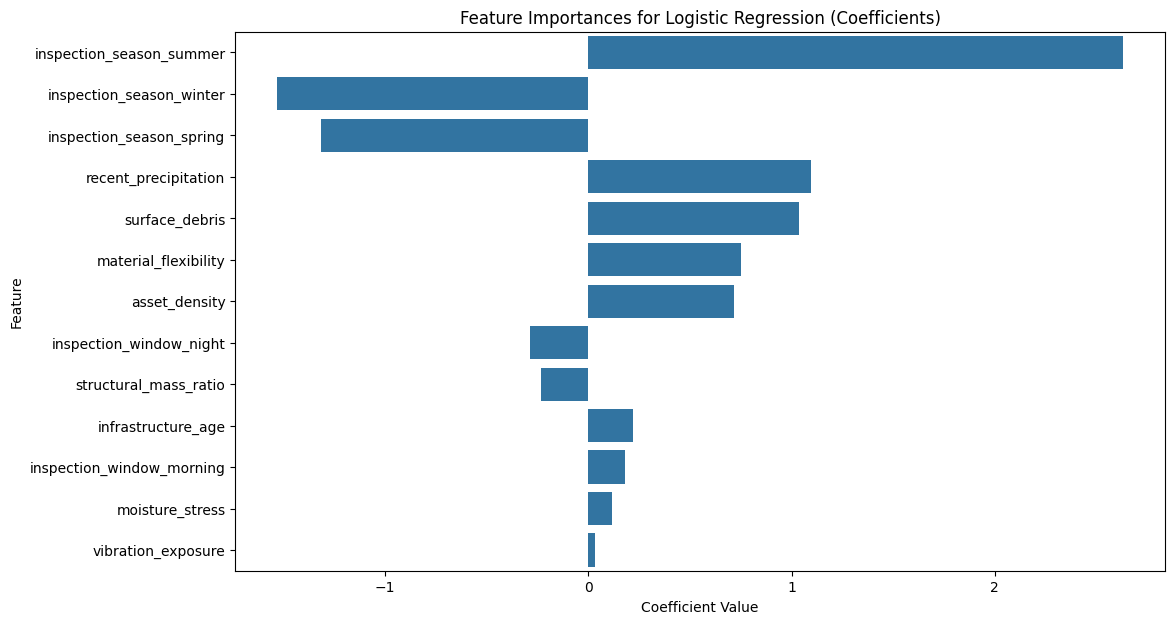

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=logreg_feature_importance_df)
plt.title('Feature Importances for Logistic Regression (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


Blocks inspected in summer are much more likely to experience failure.

That suggests:

Heat stress

Thermal expansion

Increased load

This is a dominant signal.

Winter reduces failure probability relative to the baseline season.

Spring also negative but smaller magnitude.

Important:
One season is your baseline (likely autumn).
These are relative to that.

```markdown
## Analyze Feature Importance for Random Forest

### Subtask:
Extract the feature importances from the trained Random Forest model and create a DataFrame to store them along with their corresponding feature names. Then, sort these importances to identify the most influential features.

#### Instructions:
1. Access the `model` step (which is the `RandomForestClassifier` object) from the 'Random Forest' pipeline within the `models_default` dictionary.
2. Extract the `feature_importances_` attribute from the Random Forest model.
3. Create a pandas DataFrame with two columns: 'Feature' (using `transformed_feature_names`) and 'Importance' (using the extracted feature importances).
4. Sort the DataFrame by 'Importance' in descending order to identify the most impactful features.
```

In [ ]:
rf_model = models_no_inspector["Random Forest"].named_steps["model"]
rf_importances = rf_model.feature_importances_
print(f"Extracted {len(rf_importances)} feature importances from Random Forest model.")

Extracted 13 feature importances from Random Forest model.


In [ ]:
rf_feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': rf_importances
})
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)
print("Random Forest feature importance DataFrame created and sorted.")
print(rf_feature_importance_df.head())

Random Forest feature importance DataFrame created and sorted.
                    Feature  Importance
4            surface_debris    0.207126
6             asset_density    0.193959
9  inspection_season_summer    0.127782
0      material_flexibility    0.110226
1     structural_mass_ratio    0.097122


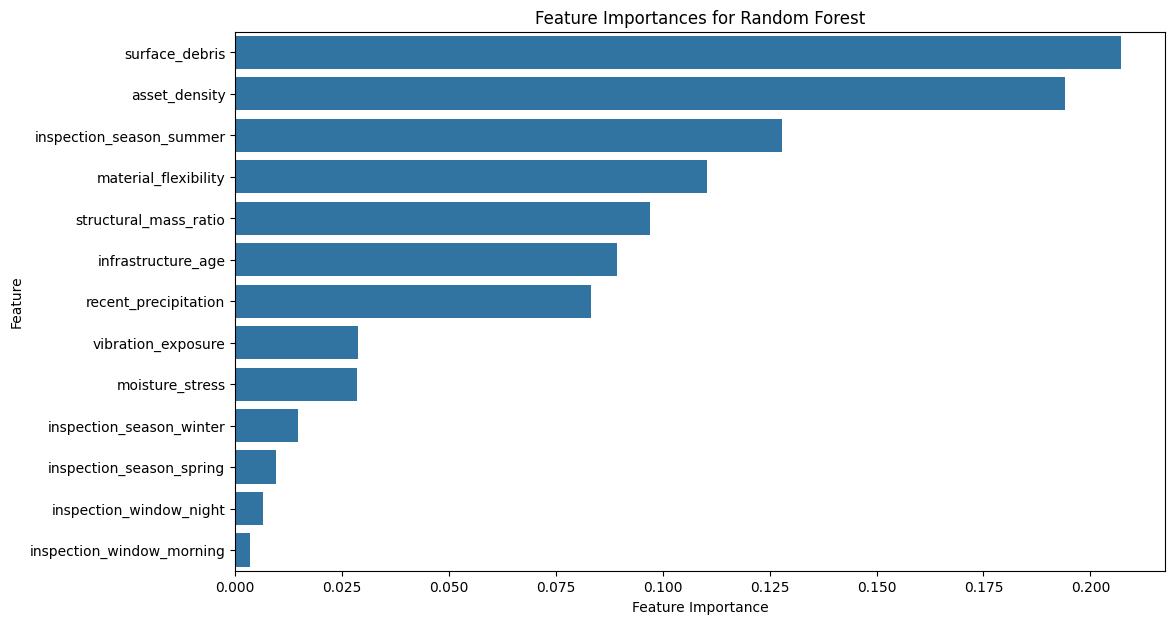

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df)
plt.title('Feature Importances for Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

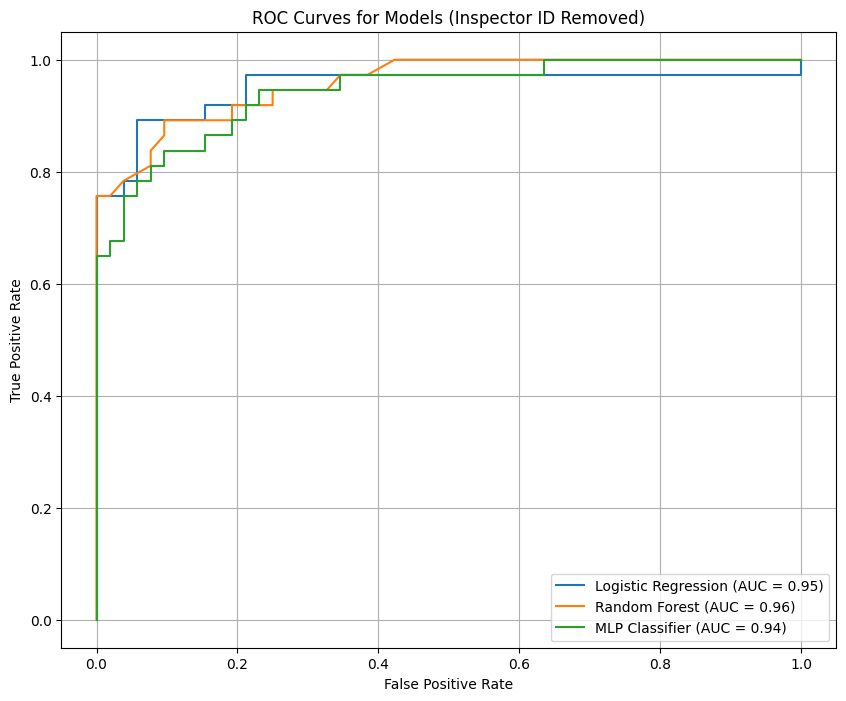

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Loop through each model trained without inspector_id
for model_name, model_pipeline in models_no_inspector.items():
    # Get probability predictions for the positive class
    y_pred_proba = model_pipeline.predict_proba(x_test_transform)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models (Inspector ID Removed)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Task
Perform hyperparameter tuning on the Logistic Regression, Random Forest, and MLP Classifier models using `GridSearchCV` on the `models_no_inspector` pipelines. Define appropriate parameter grids for each model, fit the grid search to the training data (`x_train_transform`, `y_train`), and identify the best hyperparameters and their corresponding cross-validation scores. Finally, summarize these optimal parameters and scores for all tuned models.

## import_gridsearchcv

### Subtask:
Import GridSearchCV from sklearn.model_selection to perform hyperparameter tuning.


**Reasoning**:
The subtask requires importing `GridSearchCV` from `sklearn.model_selection`. I will create a code block to perform this import.



In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [ ]:
param_grid_logreg = {
    'model__C': np.logspace(-3, 2, 10),
    'model__solver': ['liblinear', 'lbfgs'],
    'model__class_weight': [None, 'balanced']
}

Logistic regression is a low-variance model already.

In [ ]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 4]
}

In [ ]:
param_grid_mlp = {
    'model__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01]
}

In [ ]:
grid_search_logreg = GridSearchCV(
    models_no_inspector["Logistic Regression"],
    param_grid_logreg,
    cv=4,
    scoring=['recall','f1'],
    n_jobs=-1,
    refit='f1'
)

grid_search_logreg.fit(x_train_transform, y_train)

print("Best parameters for Logistic Regression:", grid_search_logreg.best_params_)
print("Best cross-validation score for Logistic Regression:", grid_search_logreg.best_score_)

results = pd.DataFrame(grid_search_logreg.cv_results_)
results_sorted = results.sort_values(by="mean_test_f1", ascending=False)

top_5 = results_sorted.head(5)

print(top_5[["params",
              "mean_test_recall",
              "std_test_recall",
              "mean_test_f1",
              "std_test_f1"]])

Best parameters for Logistic Regression: {'model__C': np.float64(0.046415888336127795), 'model__class_weight': None, 'model__solver': 'liblinear'}
Best cross-validation score for Logistic Regression: 0.8921568589469171
                                               params  mean_test_recall  \
12  {'model__C': 0.046415888336127795, 'model__cla...          0.882056   
8   {'model__C': 0.01291549665014884, 'model__clas...          0.897681   
20  {'model__C': 0.5994842503189409, 'model__class...          0.874244   
15  {'model__C': 0.046415888336127795, 'model__cla...          0.882056   
18  {'model__C': 0.1668100537200059, 'model__class...          0.905746   

    std_test_recall  mean_test_f1  std_test_f1  
12         0.040177      0.892157     0.025047  
8          0.013153      0.891047     0.022610  
20         0.058073      0.890967     0.040232  
15         0.025252      0.889129     0.029033  
18         0.053842      0.887597     0.031718  


Hyperparameter tuning has worked for Test recall. Mean used to be 84 now it is 89

In [ ]:
grid_search_rf = GridSearchCV(
    models_no_inspector["Random Forest"],
    param_grid_rf,
    cv=3,
    scoring=['recall','f1'],
    n_jobs=-1,
    refit='f1')
grid_search_rf.fit(x_train_transform, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation score for Random Forest:", grid_search_rf.best_score_)

results = pd.DataFrame(grid_search_rf.cv_results_)
results_sorted = results.sort_values(by="mean_test_f1", ascending=False)

top_5 = results_sorted.head(5)

print(top_5[["params",
              "mean_test_recall",
              "std_test_recall",
              "mean_test_f1",
              "std_test_f1"]])

Best parameters for Random Forest: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best cross-validation score for Random Forest: 0.8748793469567855
                                               params  mean_test_recall  \
1   {'model__max_depth': 10, 'model__min_samples_l...          0.873939   
2   {'model__max_depth': 10, 'model__min_samples_l...          0.873939   
5   {'model__max_depth': 10, 'model__min_samples_l...          0.873939   
20  {'model__max_depth': None, 'model__min_samples...          0.873939   
23  {'model__max_depth': None, 'model__min_samples...          0.873939   

    std_test_recall  mean_test_f1  std_test_f1  
1           0.02997      0.874879      0.02177  
2           0.02997      0.874879      0.02177  
5           0.02997      0.874879      0.02177  
20          0.02997      0.874879      0.02177  
23          0.02997      0.874879      0.02177  


In [ ]:
grid_search_mlp = GridSearchCV(
    models_no_inspector["MLP Classifier"],
    param_grid_mlp, cv=3,
     scoring=['recall','f1'],
    n_jobs=-1,
    refit='f1')
grid_search_mlp.fit(x_train_transform, y_train)

print("Best parameters for MLP Classifier:", grid_search_mlp.best_params_)
print("Best cross-validation score for MLP Classifier:", grid_search_mlp.best_score_)

results = pd.DataFrame(grid_search_mlp.cv_results_)
results_sorted = results.sort_values(by="mean_test_f1", ascending=False)

top_5 = results_sorted.head(5)

print(top_5[["params",
              "mean_test_recall",
              "std_test_recall",
              "mean_test_f1",
              "std_test_f1"]])

Best parameters for MLP Classifier: {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100,)}
Best cross-validation score for MLP Classifier: 0.8827487888559763
                                               params  mean_test_recall  \
16  {'model__activation': 'tanh', 'model__alpha': ...          0.858066   
13  {'model__activation': 'tanh', 'model__alpha': ...          0.858066   
10  {'model__activation': 'tanh', 'model__alpha': ...          0.858066   
0   {'model__activation': 'relu', 'model__alpha': ...          0.881875   
6   {'model__activation': 'relu', 'model__alpha': ...          0.881875   

    std_test_recall  mean_test_f1  std_test_f1  
16         0.034343      0.882749     0.007354  
13         0.034343      0.882749     0.007354  
10         0.034343      0.882749     0.007354  
0          0.038903      0.882328     0.021817  
6          0.038903      0.882328     0.021817  


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print("\n--- Evaluating Best Tuned Models (Inspector ID Removed) ---")

tuned_models = {
    "Logistic Regression (Tuned)": grid_search_logreg.best_estimator_,
    "Random Forest (Tuned)": grid_search_rf.best_estimator_,
    "MLP Classifier (Tuned)": grid_search_mlp.best_estimator_
}

for model_name, model_pipeline in tuned_models.items():
    print(f"\n--- Evaluating {model_name} ---")
    y_pred = model_pipeline.predict(x_test_transform)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Evaluating Best Tuned Models (Inspector ID Removed) ---

--- Evaluating Logistic Regression (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94        52
           1       0.97      0.84      0.90        37

    accuracy                           0.92        89
   macro avg       0.93      0.91      0.92        89
weighted avg       0.93      0.92      0.92        89

Confusion Matrix:
[[51  1]
 [ 6 31]]

--- Evaluating Random Forest (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90        52
           1       0.88      0.81      0.85        37

    accuracy                           0.88        89
   macro avg       0.88      0.87      0.87        89
weighted avg       0.88      0.88      0.88        89

Confusion Matrix:
[[48  4]
 [ 7 30]]

--- Evaluating MLP Classifier (Tuned) ---
Classification Report:
         

In [ ]:
threshold = 0.54

print("\n--- Evaluating Best Tuned Models with Threshold 0.3 ---")

tuned_models = {
    "Logistic Regression (Tuned)": grid_search_logreg.best_estimator_,
    "Random Forest (Tuned)": grid_search_rf.best_estimator_,
    "MLP Classifier (Tuned)": grid_search_mlp.best_estimator_
}

for model_name, model_pipeline in tuned_models.items():
    print(f"\n--- Evaluating {model_name} ---")

    # Get probabilities for class 1
    probs = model_pipeline.predict_proba(x_test_transform)[:, 1]

    # Apply custom threshold
    y_pred_thresh = (probs >= threshold).astype(int)

    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresh))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))


--- Evaluating Best Tuned Models with Threshold 0.3 ---

--- Evaluating Logistic Regression (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        52
           1       0.97      0.81      0.88        37

    accuracy                           0.91        89
   macro avg       0.92      0.90      0.90        89
weighted avg       0.92      0.91      0.91        89

Confusion Matrix:
[[51  1]
 [ 7 30]]

--- Evaluating Random Forest (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.94      0.81      0.87        37

    accuracy                           0.90        89
   macro avg       0.91      0.89      0.89        89
weighted avg       0.90      0.90      0.90        89

Confusion Matrix:
[[50  2]
 [ 7 30]]

--- Evaluating MLP Classifier (Tuned) ---
Classification Report:
             

In [ ]:

# --- Evaluating Logistic Regression with Inspector ID Removed ---
# Classification Report:
#               precision    recall  f1-score   support

#            0       0.98      0.89      0.93        55
#            1       0.85      0.97      0.90        34

#     accuracy                           0.92        89
#    macro avg       0.91      0.93      0.92        89
# weighted avg       0.93      0.92      0.92        89

# Confusion Matrix:
# [[49  6]
#  [ 1 33]]

# --- Evaluating Random Forest with Inspector ID Removed ---
# Classification Report:
#               precision    recall  f1-score   support

#            0       0.98      0.85      0.91        55
#            1       0.80      0.97      0.88        34

#     accuracy                           0.90        89
#    macro avg       0.89      0.91      0.90        89
# weighted avg       0.91      0.90      0.90        89

# Confusion Matrix:
# [[47  8]
#  [ 1 33]]

# --- Evaluating MLP Classifier with Inspector ID Removed ---
# Classification Report:
#               precision    recall  f1-score   support

#            0       0.93      0.78      0.85        55
#            1       0.72      0.91      0.81        34

#     accuracy                           0.83        89
#    macro avg       0.83      0.85      0.83        89
# weighted avg       0.85      0.83      0.83        89

# Confusion Matrix:
# [[43 12]
#  [ 3 31]]

It hurt recall so I would have to change it to f1 most likely

In [ ]:
tuned_models = {
    "Logistic Regression (Tuned)": grid_search_logreg.best_estimator_,
    "Random Forest (Tuned)": grid_search_rf.best_estimator_,
    "MLP Classifier (Tuned)": grid_search_mlp.best_estimator_
}

In [ ]:
grid_search_logreg.best_params_

{'model__C': np.float64(0.046415888336127795),
 'model__class_weight': None,
 'model__solver': 'liblinear'}

In [ ]:
grid_search_rf.best_params_

{'model__max_depth': 10,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200}

In [ ]:
grid_search_mlp.best_params_

{'model__activation': 'tanh',
 'model__alpha': 0.0001,
 'model__hidden_layer_sizes': (100,)}

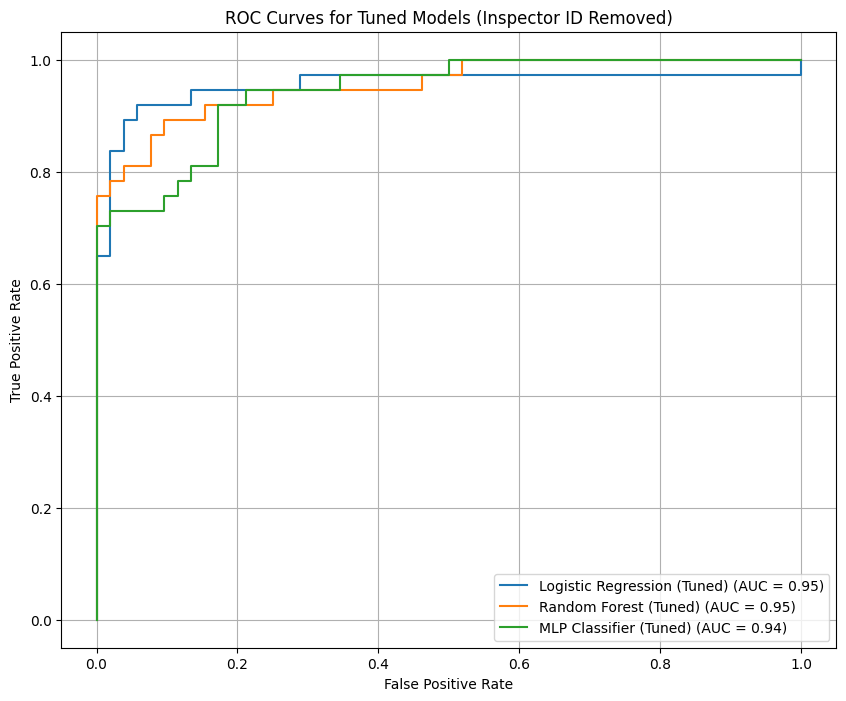

In [ ]:
plt.figure(figsize=(10, 8))

# Loop through tuned models
for model_name, model_pipeline in tuned_models.items():
    # Get probability predictions for the positive class
    y_pred_proba = model_pipeline.predict_proba(x_test_transform)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Tuned Models (Inspector ID Removed)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()